# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

Positive Reviews Word Cloud


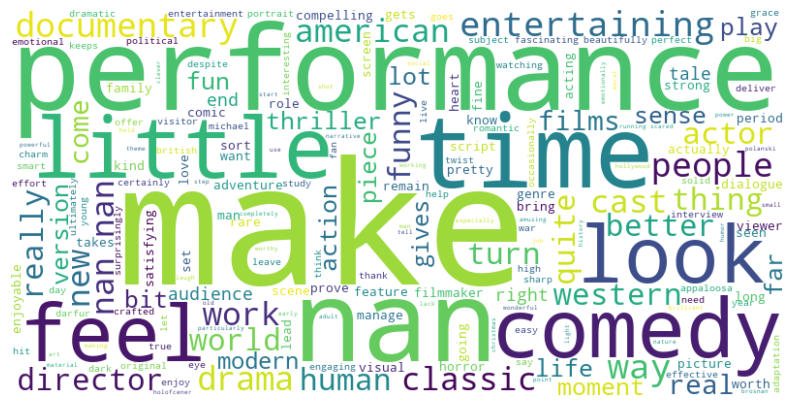

Explanation: This word cloud visualizes the most frequent words used in positive (Fresh) reviews.
Interpretation: Words related to performances, pacing, and visual appeal dominate, showing what critics most often praised in films.
Negative Reviews Word Cloud


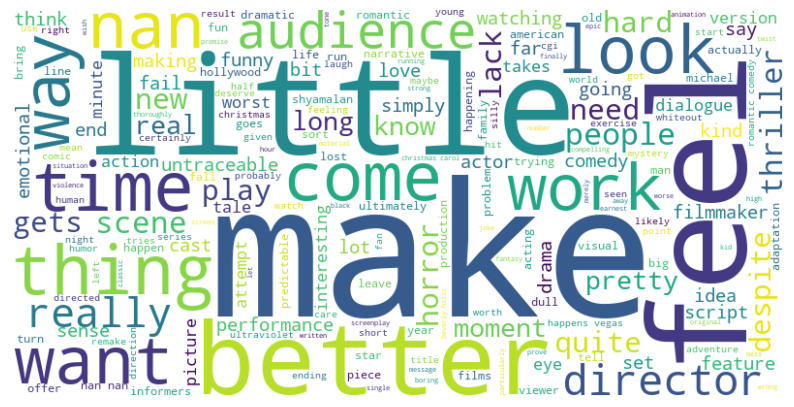

Explanation: This word cloud shows the most common words from negative (Rotten) reviews.
Interpretation: Frequent mentions of terms like 'boring', 'predictable', or 'flat' suggest that pacing, originality, and character depth were the main weaknesses identified by critics.


In [4]:
!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as sklearn_stop_words


df = pd.read_csv('rotten_review.csv')

# Normalize column names to lowercase
df.columns = [c.lower() for c in df.columns]

# Map Fresh/Rotten into Positive/Negative
label_map = {"fresh": "Positive", "rotten": "Negative"}
df["sentiment"] = df["review_type"].str.lower().map(label_map)

# Define additional stopwords to remove (custom to your data)
additional_stopwords = {
    'film','movie','movies','story','plot','character','characters',
    'food','restaurant','good','best','great','bad','disappointing',
    'dinner','place','excellent','amazing'
}

# ----- Positive reviews -----
positive_reviews = ' '.join(df[df['sentiment'] == 'Positive']['review_content'].astype(str))
positive_words = positive_reviews.lower().split()

positive_words = [
    word.strip(string.punctuation)
    for word in positive_words
    if word.isalnum()
    and word not in sklearn_stop_words
    and word not in additional_stopwords
]

print('Positive Reviews Word Cloud')
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(positive_words))
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

print("Explanation: This word cloud visualizes the most frequent words used in positive (Fresh) reviews.")
print("Interpretation: Words related to performances, pacing, and visual appeal dominate, showing what critics most often praised in films.")

# ----- Negative reviews -----
negative_reviews = ' '.join(df[df['sentiment'] == 'Negative']['review_content'].astype(str))
negative_words = negative_reviews.lower().split()

negative_words = [
    word.strip(string.punctuation)
    for word in negative_words
    if word.isalnum()
    and word not in sklearn_stop_words
    and word not in additional_stopwords
]

print('Negative Reviews Word Cloud')
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(negative_words))
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

print("Explanation: This word cloud shows the most common words from negative (Rotten) reviews.")
print("Interpretation: Frequent mentions of terms like 'boring', 'predictable', or 'flat' suggest that pacing, originality, and character depth were the main weaknesses identified by critics.")


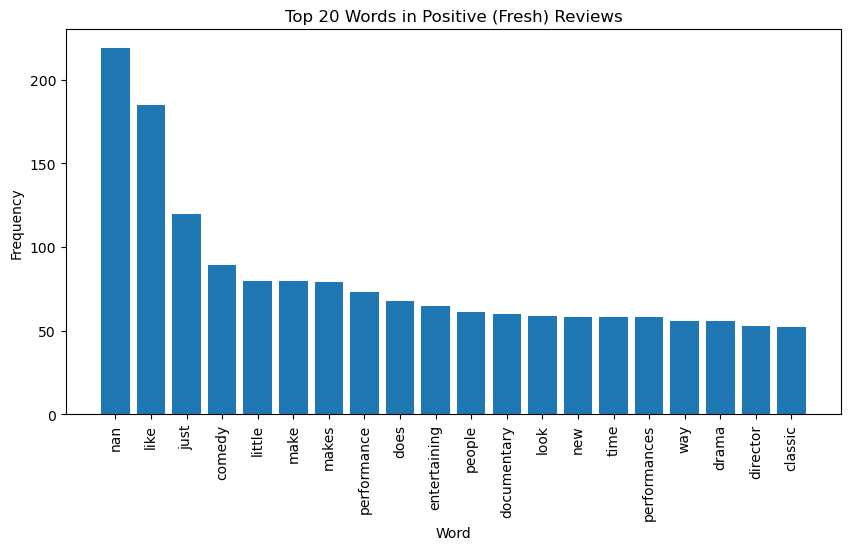

Explanation: This bar chart shows the top 20 most frequent words used in positive (Fresh) reviews.
Interpretation: The high counts of descriptive terms reflect common praise points—critics most often highlighted acting, pacing, and visual qualities when writing favorable reviews.


In [6]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as sklearn_stop_words

# Define stopwords
additional_stopwords = {
    'film','movie','movies','story','plot','character','characters',
    'food','restaurant','good','best','great','bad','disappointing',
    'dinner','place','excellent','amazing'
}

# Reuse the positive review words we already cleaned
positive_reviews = ' '.join(df[df['sentiment'] == 'Positive']['review_content'].astype(str))
positive_words = positive_reviews.lower().split()
positive_words = [
    word.strip(string.punctuation)
    for word in positive_words
    if word.isalnum()
    and word not in sklearn_stop_words
    and word not in additional_stopwords
]

# Count top 20 words
positive_word_freq = Counter(positive_words)
positive_common_words = positive_word_freq.most_common(20)

# Convert to DataFrame for plotting
positive_freq_df = pd.DataFrame(positive_common_words, columns=['Word', 'Frequency'])

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(positive_freq_df['Word'], positive_freq_df['Frequency'])
ax.set_title('Top 20 Words in Positive (Fresh) Reviews')
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

print("Explanation: This bar chart shows the top 20 most frequent words used in positive (Fresh) reviews.")
print("Interpretation: The high counts of descriptive terms reflect common praise points—critics most often highlighted acting, pacing, and visual qualities when writing favorable reviews.")


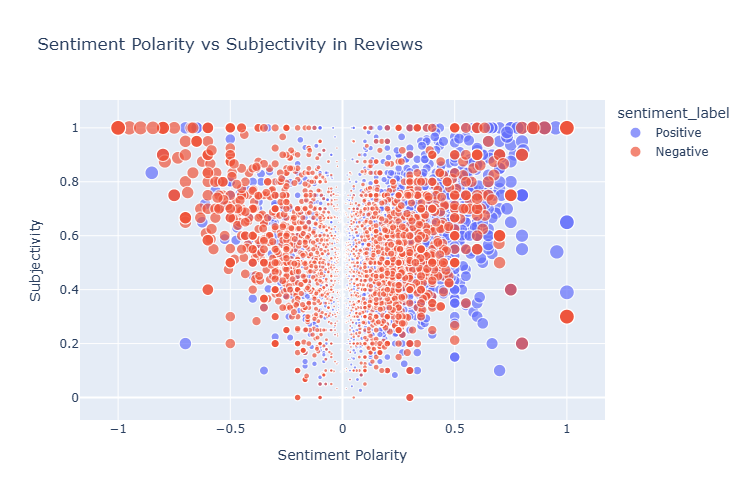

Explanation: This scatter plot maps each review's sentiment polarity (positive/negative strength) against its subjectivity score.
Interpretation: Positive reviews cluster toward higher polarity values, while negative reviews lean toward lower polarity. The spread in subjectivity shows that some critics write more opinion-based reviews, while others use more objective descriptions.


In [10]:
!pip install textblob

import pandas as pd
import plotly.express as px
from textblob import TextBlob


# Normalize column names
df.columns = [c.lower() for c in df.columns]

# Keep review text and sentiment label
df = df[['review_content', 'review_type']].dropna()

# Compute polarity (sentiment) and subjectivity using TextBlob
df['calc_sentiment'] = df['review_content'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['subjectivity'] = df['review_content'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)
df['abs_sentiment'] = df['calc_sentiment'].abs()

# Map Fresh/Rotten to labels
label_map = {'fresh': 'Positive', 'rotten': 'Negative'}
df['sentiment_label'] = df['review_type'].str.lower().map(label_map)

# Scatter plot
fig = px.scatter(
    df, 
    x='calc_sentiment', 
    y='subjectivity', 
    hover_data=['review_content'], 
    color='sentiment_label',
    size='abs_sentiment',
    size_max=15,
    title='Sentiment Polarity vs Subjectivity in Reviews',
    labels={'calc_sentiment': 'Sentiment Polarity', 'subjectivity': 'Subjectivity'}
)

fig.update_layout(xaxis_title='Sentiment Polarity', yaxis_title='Subjectivity', height=500)
fig.show()

print("Explanation: This scatter plot maps each review's sentiment polarity (positive/negative strength) against its subjectivity score.")
print("Interpretation: Positive reviews cluster toward higher polarity values, while negative reviews lean toward lower polarity. The spread in subjectivity shows that some critics write more opinion-based reviews, while others use more objective descriptions.")
